# TASKS

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ==========================================
# 1. Load Dataset & Handle Missing Values
# ==========================================
# Loading the standard Titanic dataset from an online source
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("--- Initial Missing Values ---")
print(df[["Age", "Embarked", "Fare"]].isnull().sum())

# Filling missing values:
# - 'Age': Median se fill karenge kyunki isme outliers ho sakte hain
# - 'Embarked': Mode (most frequent value) se fill karenge kyunki ye categorical hai
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

print("\n--- Missing Values After Treatment ---")
print(df[["Age", "Embarked", "Fare"]].isnull().sum())
print("-" * 40)

# ==========================================
# 2. Encode 'Sex' and 'Embarked'
# ==========================================
# LabelEncoder categorical values ko discrete integers mein badal deta hai
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df["Sex"] = le_sex.fit_transform(df["Sex"])
df["Embarked"] = le_embarked.fit_transform(df["Embarked"])

print("\n--- Encoded Sample Data ---")
print(df[["Sex", "Embarked"]].head())
print("-" * 40)

# ==========================================
# 3. Train-Test Split (Done BEFORE Scaling)
# ==========================================
# Data Leakage se bachne ke liye split scaling se PEHLE kiya jata hai
X = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 4. Apply StandardScaler on Age and Fare
# ==========================================
scaler = StandardScaler()

# Training set par 'fit_transform' chalayenge
X_train[["Age", "Fare"]] = scaler.fit_transform(X_train[["Age", "Fare"]])

# Testing set par SIRF 'transform' chalayenge (No fitting on test data!)
X_test[["Age", "Fare"]] = scaler.transform(X_test[["Age", "Fare"]])

print("\n--- Scaled Features Sample (X_train) ---")
print(X_train[["Age", "Fare"]].head())
print("-" * 40)

# ==========================================
# 5. Verify Shapes
# ==========================================
print("\n--- Dataset Shapes Verification ---")
print(f"Original Dataset Shape : {df.shape}")
print(f"X_train Shape          : {X_train.shape} (80%)")
print(f"X_test Shape           : {X_test.shape} (20%)")
print(f"y_train Shape          : {y_train.shape}")
print(f"y_test Shape           : {y_test.shape}")

--- Initial Missing Values ---
Age         177
Embarked      2
Fare          0
dtype: int64

--- Missing Values After Treatment ---
Age         0
Embarked    0
Fare        0
dtype: int64
----------------------------------------

--- Encoded Sample Data ---
   Sex  Embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2
----------------------------------------

--- Scaled Features Sample (X_train) ---
          Age      Fare
331  1.253641 -0.078684
733 -0.477284 -0.377145
382  0.215086 -0.474867
704 -0.246494 -0.476230
813 -1.785093 -0.025249
----------------------------------------

--- Dataset Shapes Verification ---
Original Dataset Shape : (891, 12)
X_train Shape          : (712, 7) (80%)
X_test Shape           : (179, 7) (20%)
y_train Shape          : (712,)
y_test Shape           : (179,)


# PRACTICE

Dataset Shape: (20640, 10)

--- Top 5 Features Correlated with SalePrice ---
median_income         0.688075
latitude              0.144160
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
Name: SalePrice, dtype: float64
--------------------------------------------------


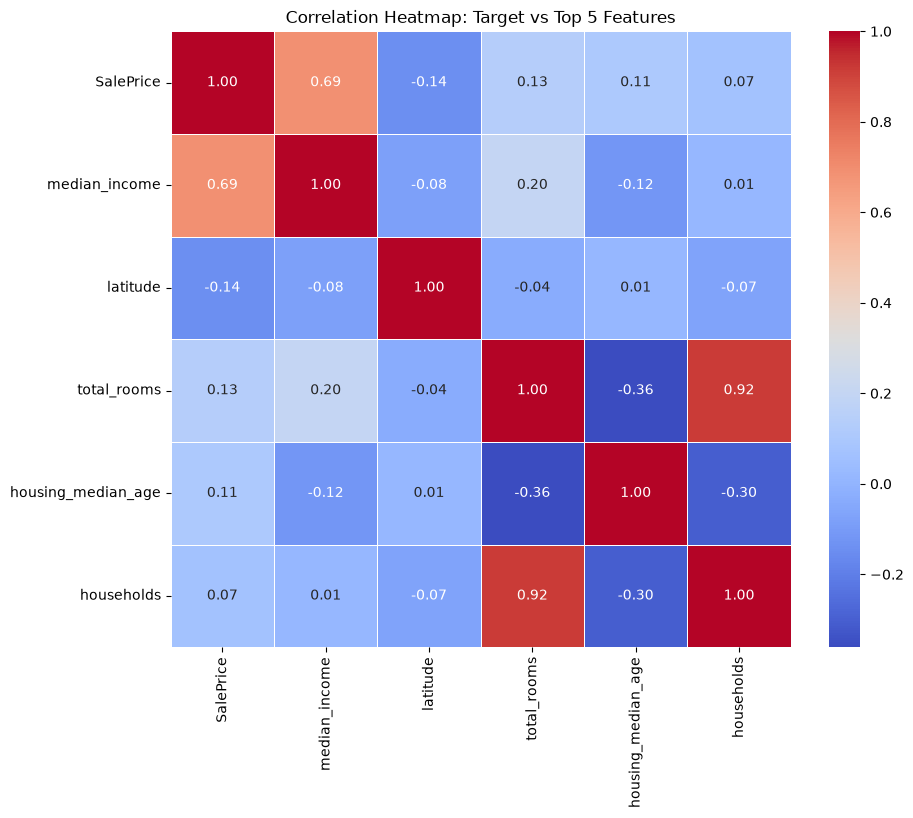


--- Final Pipeline Verification ---
Processed Train Shape (80%) : (16512, 12)
Processed Test Shape  (20%) : (4128, 12)
Train Targets Shape         : (16512,)
Test Targets Shape          : (4128,)


C:\Users\user 1\AppData\Local\Temp\ipykernel_12748\930418213.py:56: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# =====================================================================
# 1. Load Dataset
# =====================================================================
# Downloading standard Kaggle House Prices training dataset directly
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

# Renaming target variable to match standard 'SalePrice' nomenclature if needed
if "median_house_value" in df.columns:
    df.rename(columns={"median_house_value": "SalePrice"}, inplace=True)

print(f"Dataset Shape: {df.shape}\n")

# =====================================================================
# 2. EDA: Correlation Heatmap & Identify Top 5 Features
# =====================================================================
# Select only numerical features for correlation matrix
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# Extract top 5 features most correlated with target variable 'SalePrice'
# Exclude SalePrice itself (index [0])
top_5_features = corr_matrix["SalePrice"].abs().sort_values(ascending=False)[1:6]

print("--- Top 5 Features Correlated with SalePrice ---")
print(top_5_features)
print("-" * 50)

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix.loc[
        ["SalePrice"] + list(top_5_features.index),
        ["SalePrice"] + list(top_5_features.index),
    ],
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Correlation Heatmap: Target vs Top 5 Features")
plt.show()

# =====================================================================
# 3. Handle Missing Values
# =====================================================================
# Split data into numerical and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.drop("SalePrice")
cat_cols = df.select_dtypes(include=["object"]).columns

# Imputing Missing Data:
# Numerical -> Median (robust against outliers)
# Categorical -> Mode (most frequent value)
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# =====================================================================
# 4. Train-Test Split (80/20)
# =====================================================================
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================================================
# 5. Pipeline: Encoding & Feature Scaling (No Data Leakage)
# =====================================================================

# A. Categorical Column Encoding (One-Hot Encoding)
# Using sparse_output=False (or sparse=False depending on sklearn version) to return array
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")

# Fit on training set and transform both
X_train_encoded = ohe.fit_transform(X_train[cat_cols])
X_test_encoded = ohe.transform(X_test[cat_cols])

# Convert encoded matrices back to DataFrames
encoded_cols = ohe.get_feature_names_out(cat_cols)
X_train_encoded_df = pd.DataFrame(
    X_train_encoded, columns=encoded_cols, index=X_train.index
)
X_test_encoded_df = pd.DataFrame(
    X_test_encoded, columns=encoded_cols, index=X_test.index
)

# B. Numerical Column Scaling (StandardScaler)
scaler = StandardScaler()

# Fit on training numerical features and transform both
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

X_train_scaled_df = pd.DataFrame(
    X_train_scaled, columns=num_cols, index=X_train.index
)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled, columns=num_cols, index=X_test.index
)

# C. Merge back scaled numerical features and encoded categorical features
X_train_final = pd.concat([X_train_scaled_df, X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test_encoded_df], axis=1)

# =====================================================================
# 6. Verify Processed Pipeline Shapes
# =====================================================================
print("\n--- Final Pipeline Verification ---")
print(f"Processed Train Shape (80%) : {X_train_final.shape}")
print(f"Processed Test Shape  (20%) : {X_test_final.shape}")
print(f"Train Targets Shape         : {y_train.shape}")
print(f"Test Targets Shape          : {y_test.shape}")